#NLP


                    AMAZON REVIEWS SENTIMENT ANALYSIS

                                │
                                ▼

                    1. Import Required Libraries
          (Pandas, NumPy, NLTK, Sklearn, Matplotlib, Seaborn)

                                │
                                ▼

                       2. Load Amazon Reviews Dataset

                                │
                                ▼

                      3. Data Understanding (EDA)

           • Dataset Shape
           • Columns
           • Data Types
           • Missing Values
           • Duplicate Values
           • Sentiment Distribution

                                │
                                ▼

                      4. Text Preprocessing

           • Lowercase Conversion
           • Remove HTML Tags
           • Remove URLs
           • Remove Numbers
           • Remove Punctuation
           • Remove Extra Spaces
           • Stopword Removal
           • Lemmatization

                                │
                                ▼

                Clean Reviews Ready for Machine Learning

                                │
                                ▼

                  5. Exploratory Data Analysis (EDA)

           • Review Length Analysis
           • Longest Review
           • Shortest Review
           • Average Review Length
           • Positive Word Cloud
           • Negative Word Cloud
           • Most Common Positive Words
           • Most Common Negative Words

                                │
                                ▼

                  6. Feature Engineering (TF-IDF)

           Text Reviews
                 │
                 ▼
       Numerical Feature Matrix

                                │
                                ▼

                     7. Train-Test Split

               80% Training
               20% Testing

                                │
                                ▼

                    8. Model Development

          ┌───────────────────────────────┐
          │ Logistic Regression           │
          │ Linear Support Vector Machine │
          │ Neural Network (MLP)          │
          └───────────────────────────────┘

                                │
                                ▼

                      9. Model Evaluation

           • Accuracy
           • Precision
           • Recall
           • F1-Score
           • Confusion Matrix
           • Cross Validation

                                │
                                ▼

                    10. Model Comparison

         Compare All Models
         Select Best Performing Model

                                │
                                ▼

                    11. Business Conclusion

                                │
                                ▼

                        12. Future Scope

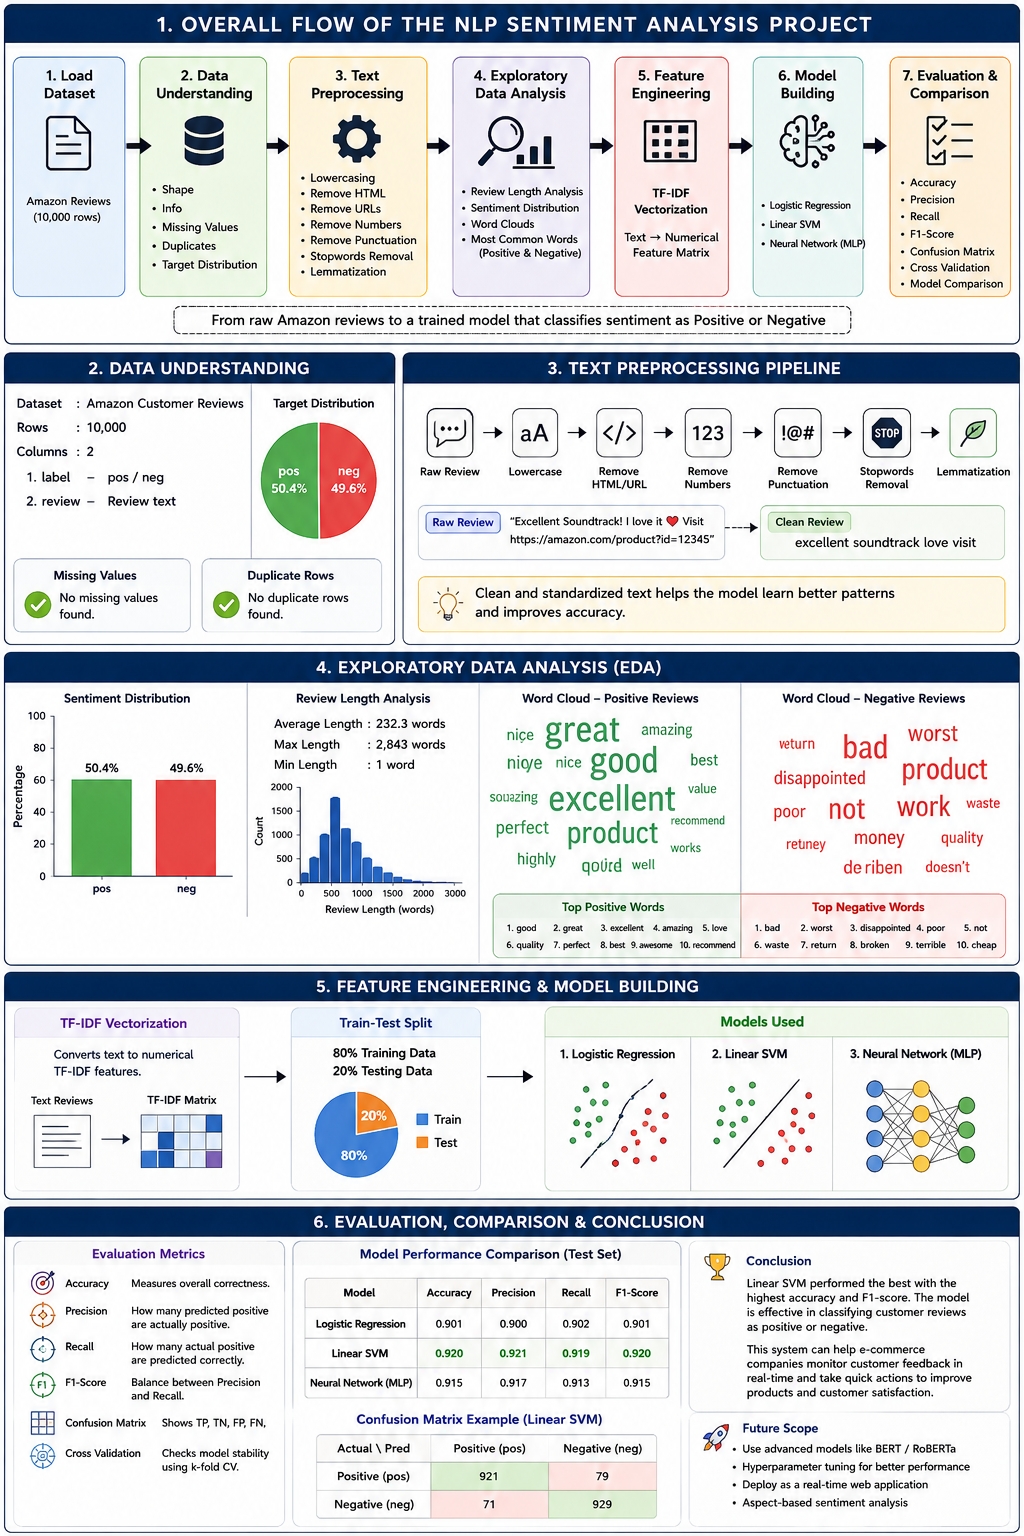

In [178]:
#IMPORT REQUIRED LIBRARIES

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Text Processing
import re
import string

# Natural Language Processing (NLP)
import nltk

# Download required NLTK resources (Run only once)
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("wordnet")

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Word Cloud
from wordcloud import WordCloud

# Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Train Test Split
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Set Plot Style
plt.style.use("ggplot")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [109]:

# LOAD THE DATASET
df = pd.read_csv("amazonreviews.tsv", sep="\t")
df.head()

,label,review
0,pos,Stuning even for the non-gamer: This sound tra...
1,pos,The best soundtrack ever to anything.: I'm rea...
2,pos,Amazing!: This soundtrack is my favorite music...
3,pos,Excellent Soundtrack: I truly like this soundt...
4,pos,"Remember, Pull Your Jaw Off The Floor After He..."


In [110]:
print("Dataset Shape :", df.shape)

Dataset Shape : (10000, 2)


In [111]:
print("Columns in Dataset :")
print(df.columns)

Columns in Dataset :
Index(['label', 'review'], dtype='object')


In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   10000 non-null  object
 1   review  10000 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


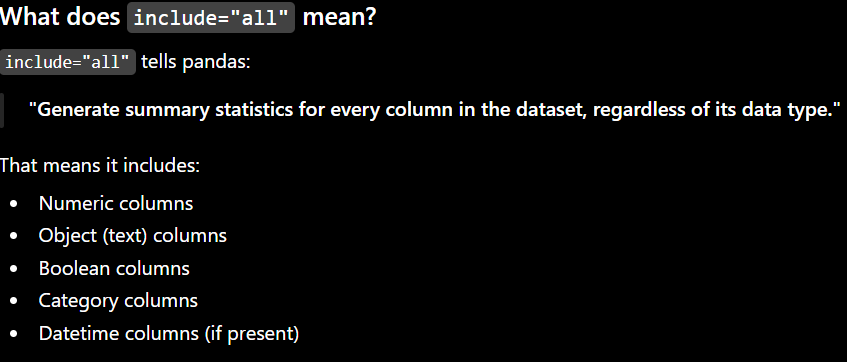

In [113]:
df.describe(include="all")

,label,review
count,10000,10000
unique,2,10000
top,neg,Early Hopkins story still sends chills through...
freq,5097,1


In [114]:
# DISPLAY RANDOM SAMPLES

# Display 5 random reviews
df.sample(5, random_state=42)

,label,review
6252,neg,"I Know I'm in the Minority Here, But...: I'm s..."
4684,neg,Disappointing: This is the 4th Clavell book I'...
1731,neg,"The writing is good, but the plot needs a lot ..."
4742,neg,"Good for a little while, but....: Sure, this t..."
4521,neg,Great For First Timers: While the flexability ...


In [115]:
df.dtypes

,0
label,object
review,object


In [116]:

# CHECK THE SIZE OF THE DATASET
print("Number of Rows    :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows    : 10000
Number of Columns : 2


In [118]:
df.isnull().sum()

,0
label,0
review,0


In [119]:

print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [120]:
# CHECK SENTIMENT DISTRIBUTION

df["label"].value_counts()

,count
label,
neg,5097
pos,4903


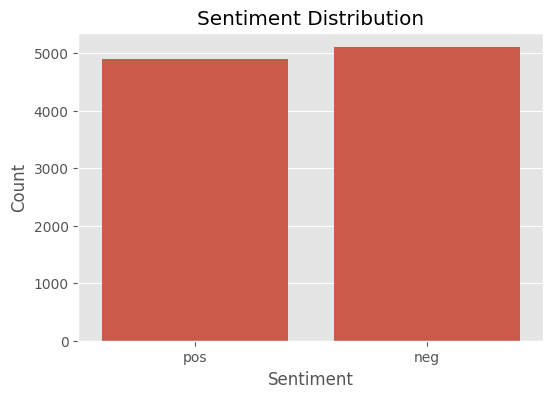

In [121]:
# VISUALIZE SENTIMENT DISTRIBUTION

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="label"
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

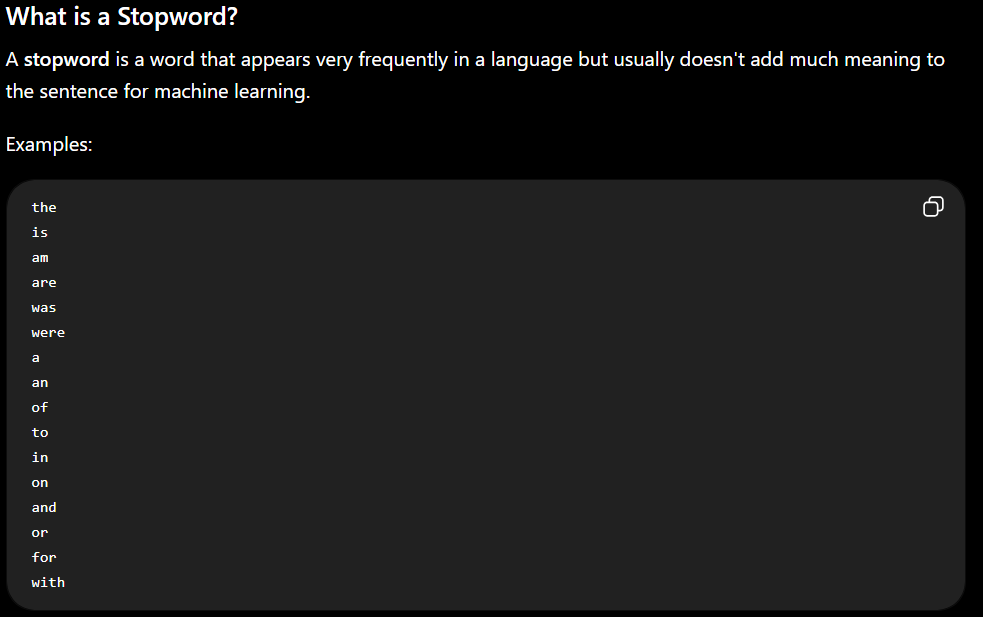

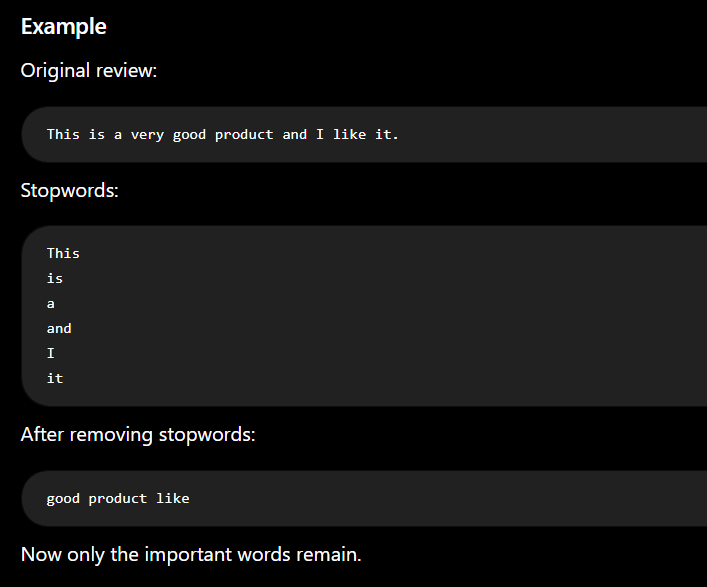

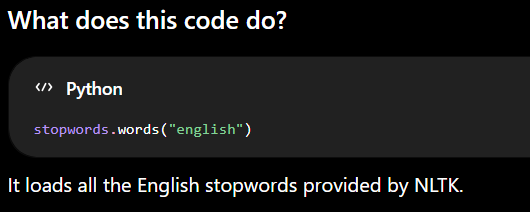

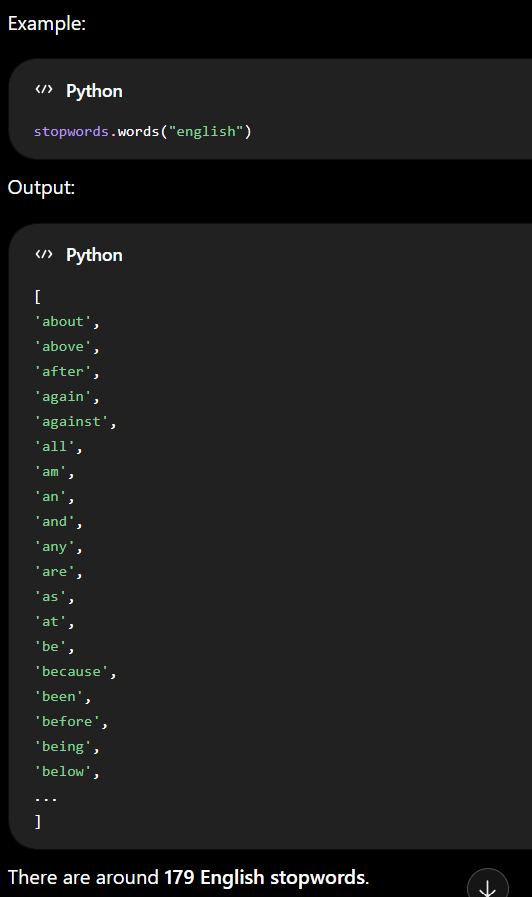

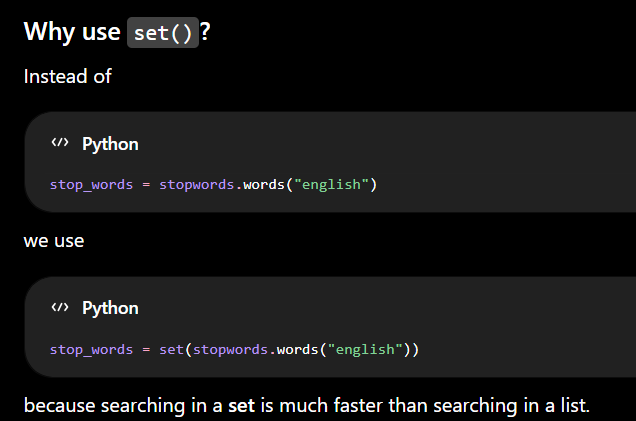

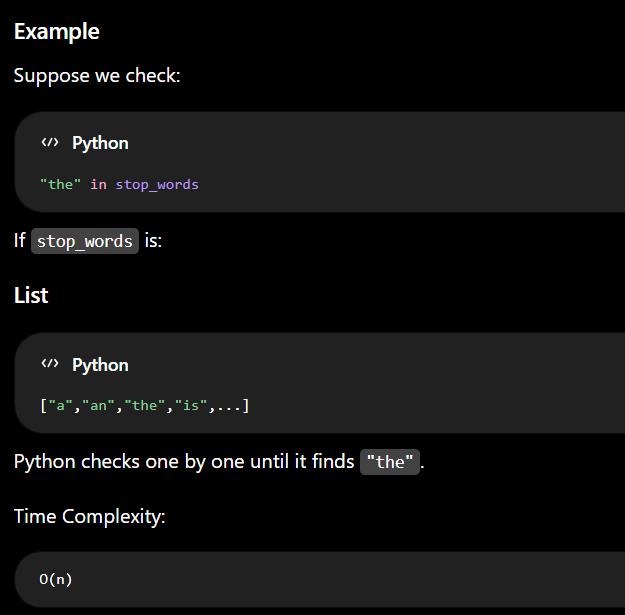

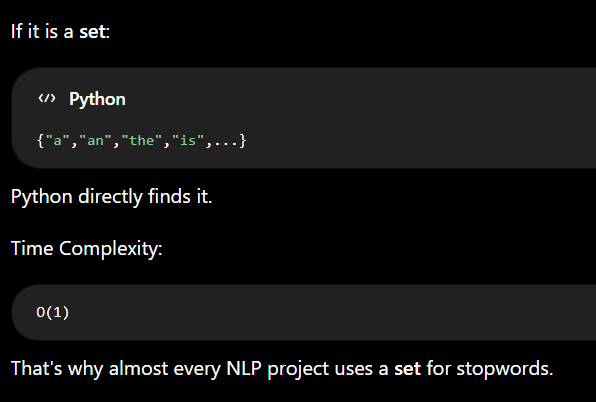

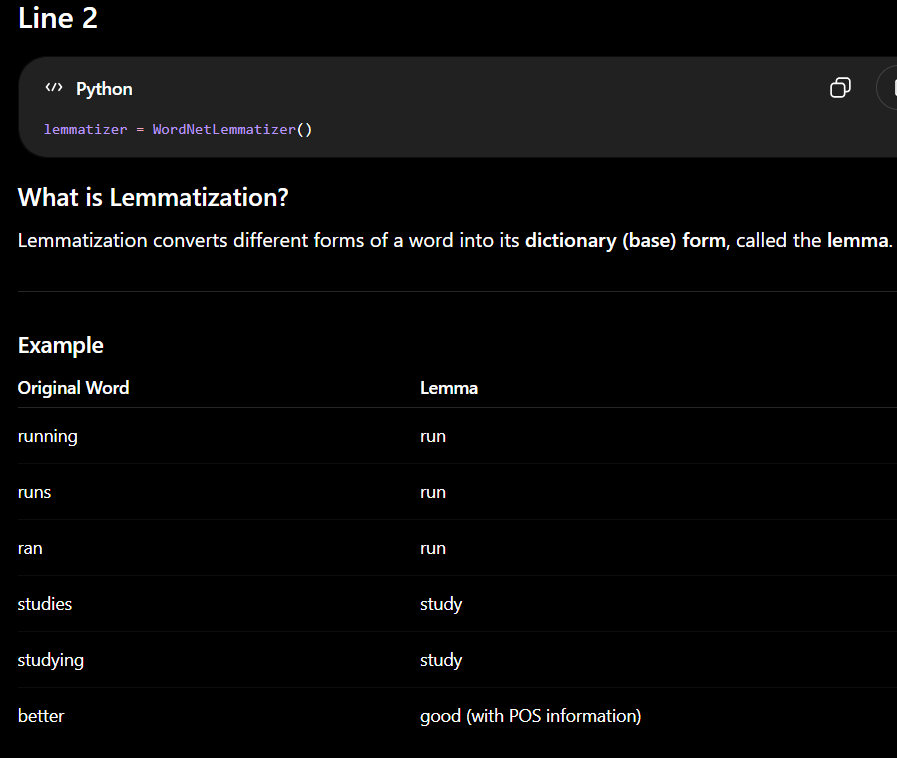

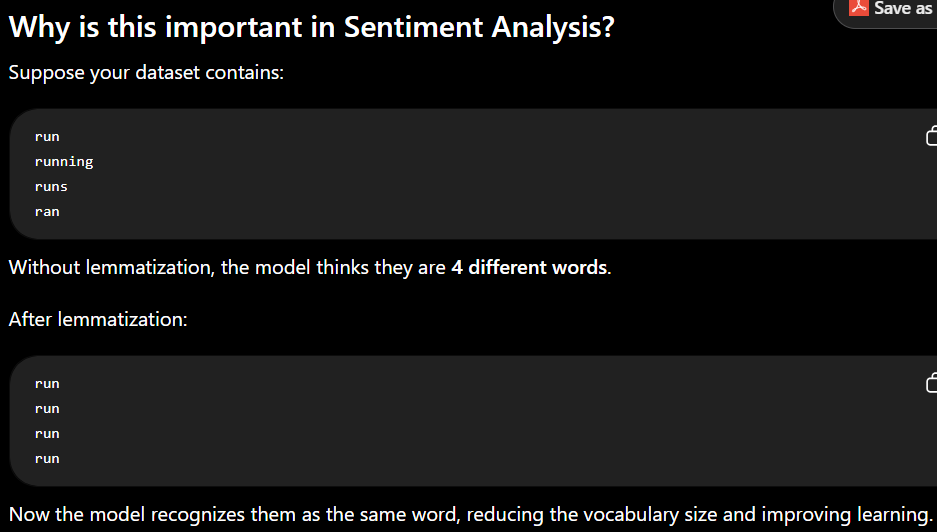

In [122]:

# CREATE STOPWORDS AND LEMMATIZER

# Load English stopwords
stop_words = set(stopwords.words("english"))

# Initialize the WordNet Lemmatizer
lemmatizer = WordNetLemmatizer()

In [123]:

# TEXT CLEANING FUNCTION

def clean_text(text):

    # Convert text to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenize the text
    words = nltk.word_tokenize(text)

    # Remove stopwords and perform lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    # Join words back into a sentence
    return " ".join(words)

In [124]:
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [125]:
# APPLY TEXT CLEANING TO THE REVIEW COLUMN

# Create a new column with cleaned reviews
df["clean_review"] = df["review"].apply(clean_text)

In [126]:
# COMPARE ORIGINAL AND CLEANED REVIEWS

df[["review", "clean_review"]].head()

,review,clean_review
0,Stuning even for the non-gamer: This sound tra...,stuning even nongamer sound track beautiful pa...
1,The best soundtrack ever to anything.: I'm rea...,best soundtrack ever anything im reading lot r...
2,Amazing!: This soundtrack is my favorite music...,amazing soundtrack favorite music time hand in...
3,Excellent Soundtrack: I truly like this soundt...,excellent soundtrack truly like soundtrack enj...
4,"Remember, Pull Your Jaw Off The Floor After He...",remember pull jaw floor hearing youve played g...


In [127]:
# CHECK EMPTY CLEANED REVIEWS

print("Empty Clean Reviews :",
      (df["clean_review"] == "").sum())

Empty Clean Reviews : 0


In [128]:
# VERIFY THE UPDATED DATASET
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   label         10000 non-null  object
 1   review        10000 non-null  object
 2   clean_review  10000 non-null  object
dtypes: object(3)
memory usage: 234.5+ KB


In [129]:

# DISPLAY RANDOM CLEANED REVIEWS

df[["label", "clean_review"]].sample(10, random_state=42)

,label,clean_review
6252,neg,know im minority im sorry spoilsport found ter...
4684,neg,disappointing th clavell book ive read little ...
1731,neg,writing good plot need lot work love book make...
4742,neg,good little sure thing definitely costeffectiv...
4521,neg,great first timer flexability nice us non stan...
6340,pos,best fire emblem yet game awesome got couldnt ...
576,pos,ahi lb kid set twin tummy squeem give beautifu...
5202,neg,omg worst movie ever haha wow one movie comple...
6363,neg,enterence video enterence videono storylinesmu...
439,neg,uneducated nonsense physic department school g...


In [130]:
# SAVE THE CLEANED DATASET

df.to_csv("amazon_reviews_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


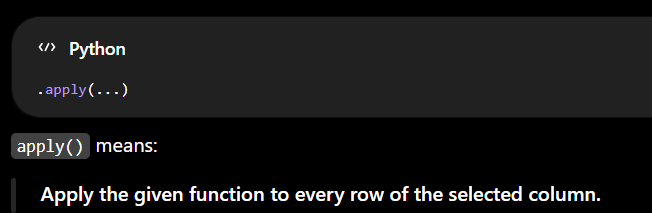

In [131]:
# CREATE REVIEW LENGTH COLUMN

# Calculate the number of words in each cleaned review
df["review_length"] = df["clean_review"].apply(lambda x: len(x.split()))

# Display the first few records
df[["clean_review", "review_length"]].head()

,clean_review,review_length
0,stuning even nongamer sound track beautiful pa...,43
1,best soundtrack ever anything im reading lot r...,49
2,amazing soundtrack favorite music time hand in...,73
3,excellent soundtrack truly like soundtrack enj...,72
4,remember pull jaw floor hearing youve played g...,47


In [132]:
# REVIEW LENGTH STATISTICS

df["review_length"].describe()

,review_length
count,10000.000000
mean,40.536400
std,21.926066
min,4.000000
25%,22.000000
50%,36.000000
75%,55.000000
max,143.000000


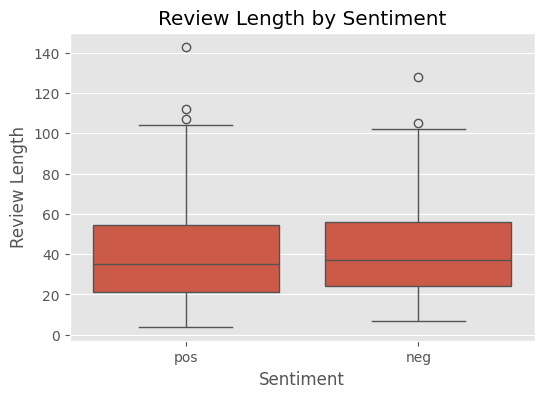

In [133]:
# REVIEW LENGTH BY SENTIMENT

plt.figure(figsize=(6,4))

sns.boxplot(
    data=df,
    x="label",
    y="review_length"
)

plt.title("Review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Review Length")

plt.show()

In [134]:
# LONGEST REVIEW

df.loc[df["review_length"].idxmax()] # notice the methods idxmax

,1249
label,pos
review,"Il grande ritorno!: E' dai tempi del tour di ""..."
clean_review,il grande ritorno e dai tempo del tour di empi...
review_length,143


In [135]:

# SHORTEST REVIEW

df.loc[df["review_length"].idxmin()] # notice the method idxmin

,881
label,pos
review,Good read................. ............... ......
clean_review,good read good read
review_length,4


In [136]:
# AVERAGE REVIEW LENGTH

print("Average Review Length :", round(df["review_length"].mean(), 2), "words")

Average Review Length : 40.54 words


In [137]:

# AVERAGE REVIEW LENGTH FOR EACH SENTIMENT

df.groupby("label")["review_length"].mean()

,review_length
label,
neg,41.303316
pos,39.739139


In [138]:
# IMPORT COUNTER

from collections import Counter

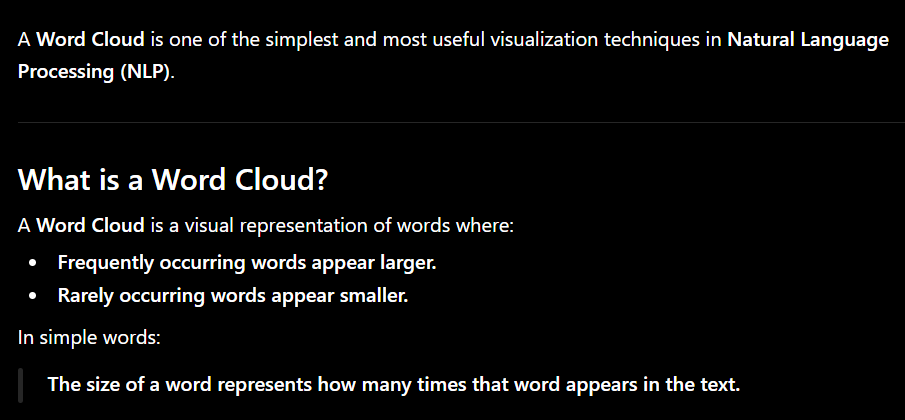

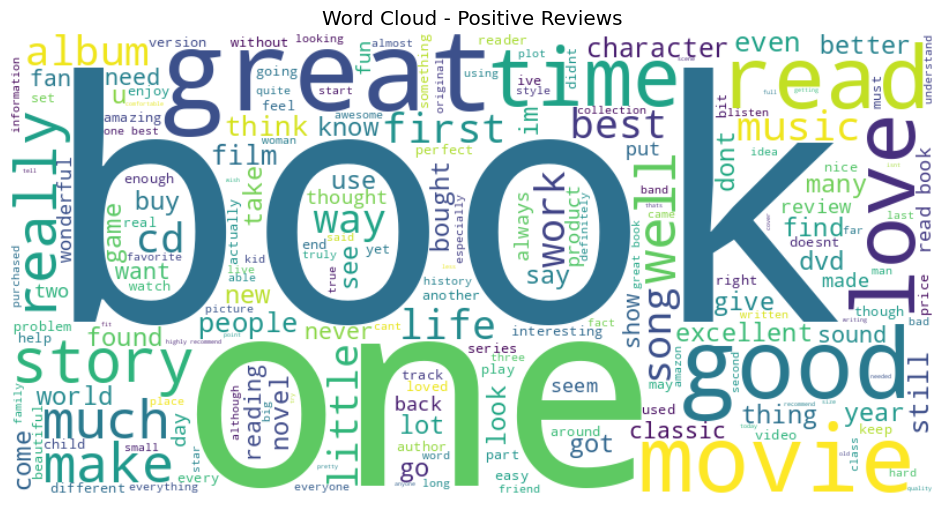

In [139]:

# WORD CLOUD FOR POSITIVE REVIEWS

# Combine all positive reviews into one string
positive_text = " ".join(df[df["label"] == "pos"]["clean_review"])

# Generate Word Cloud
positive_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(positive_text)

# Display the Word Cloud
plt.figure(figsize=(12,6))
plt.imshow(positive_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Positive Reviews")
plt.show()

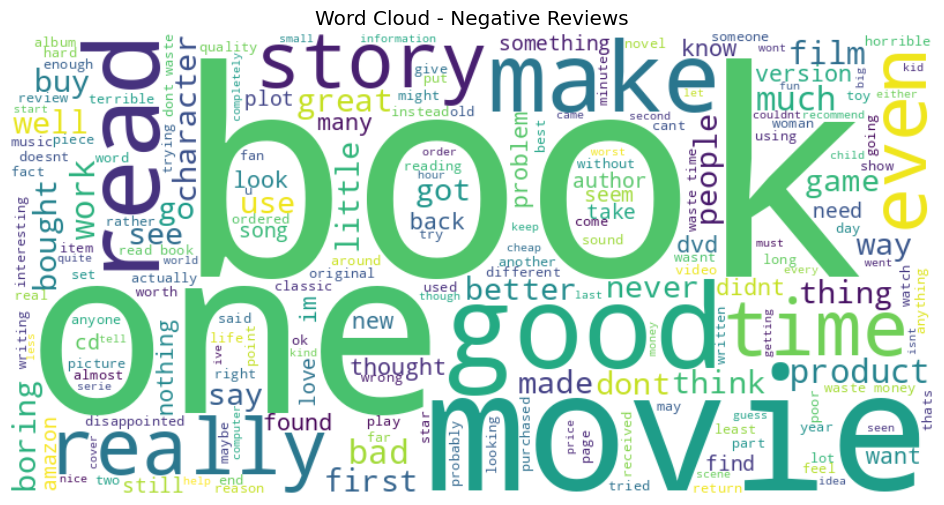

In [140]:

# WORD CLOUD FOR NEGATIVE REVIEWS

# Combine all negative reviews into one string
negative_text = " ".join(df[df["label"] == "neg"]["clean_review"])

# Generate Word Cloud
negative_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(negative_text)

# Display the Word Cloud
plt.figure(figsize=(12,6))
plt.imshow(negative_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Negative Reviews")
plt.show()

In [141]:
# TOP 20 POSITIVE WORDS

positive_words = " ".join(df[df["label"] == "pos"]["clean_review"]).split()

positive_counts = Counter(positive_words)

top_positive = pd.DataFrame(
    positive_counts.most_common(20),
    columns=["Word", "Frequency"]
)

top_positive

,Word,Frequency
0,book,3861
1,great,2089
2,one,1936
3,good,1637
4,read,1574
5,like,1320
6,movie,1295
7,time,1135
8,love,1036
9,would,943


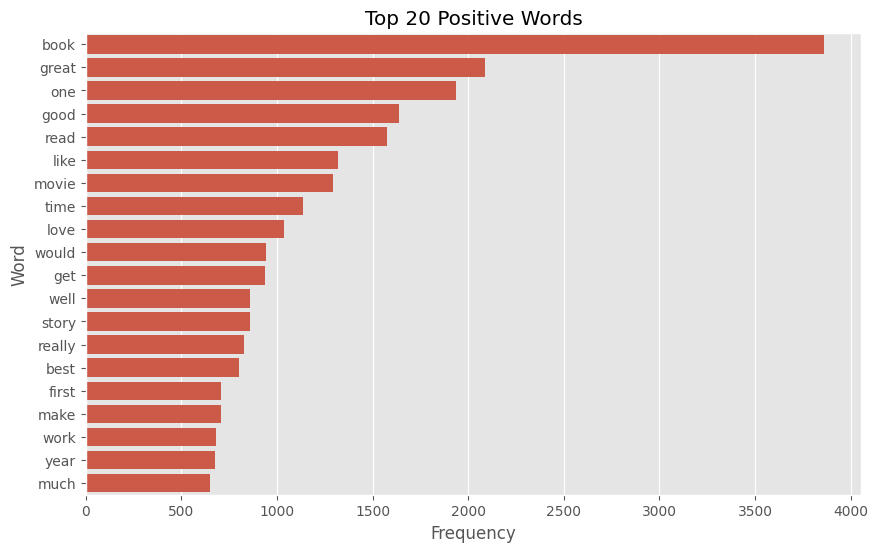

In [142]:
# VISUALIZE TOP 20 POSITIVE WORDS

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_positive,
    x="Frequency",
    y="Word"
)

plt.title("Top 20 Positive Words")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

In [143]:
# TOP 20 NEGATIVE WORDS

negative_words = " ".join(df[df["label"] == "neg"]["clean_review"]).split()

negative_counts = Counter(negative_words)

top_negative = pd.DataFrame(
    negative_counts.most_common(20),
    columns=["Word", "Frequency"]
)

top_negative

,Word,Frequency
0,book,3683
1,one,2119
2,movie,1732
3,like,1570
4,would,1438
5,get,1285
6,time,1274
7,dont,1240
8,read,1238
9,good,1137


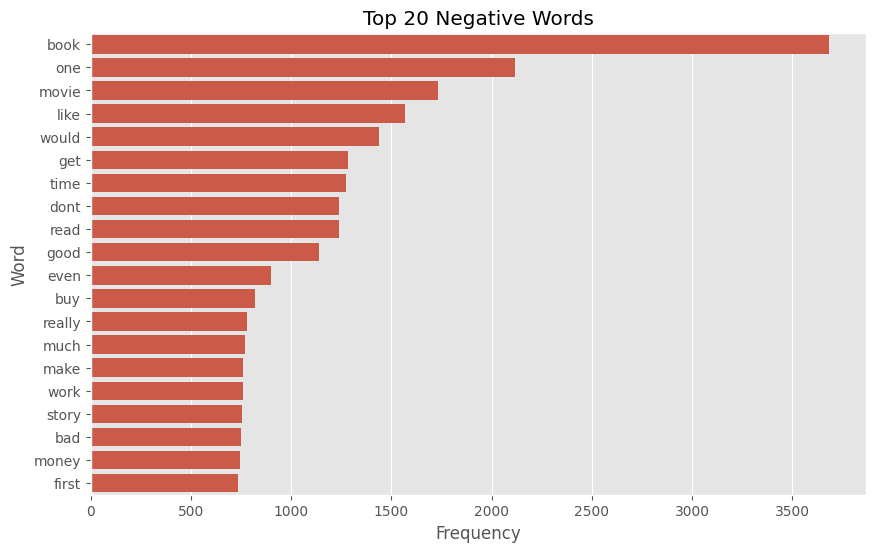

In [144]:
# VISUALIZE TOP 20 NEGATIVE WORDS

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_negative,
    x="Frequency",
    y="Word"
)

plt.title("Top 20 Negative Words")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

In [145]:
# TOP 20 WORDS OVERALL

all_words = " ".join(df["clean_review"]).split()

all_counts = Counter(all_words)

top_words = pd.DataFrame(
    all_counts.most_common(20),
    columns=["Word", "Frequency"]
)

top_words

,Word,Frequency
0,book,7544
1,one,4055
2,movie,3027
3,like,2890
4,read,2812
5,good,2774
6,great,2722
7,time,2409
8,would,2381
9,get,2221


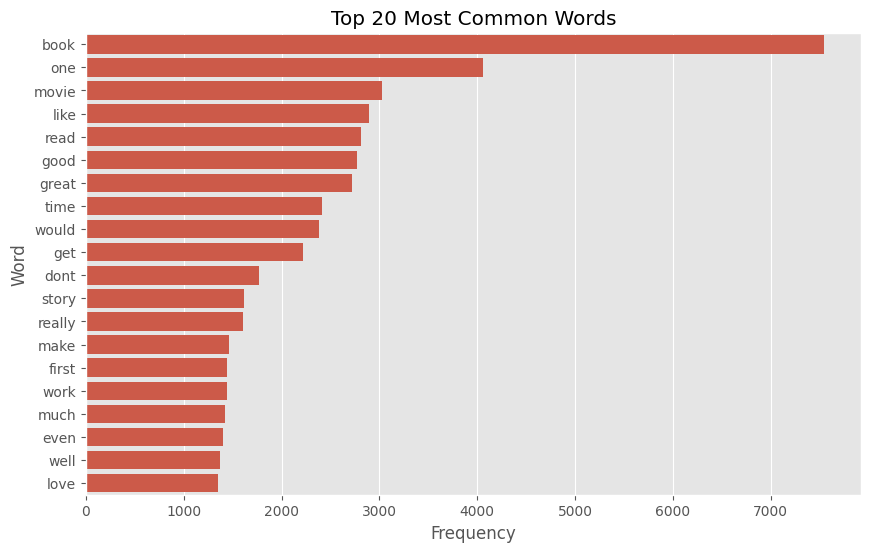

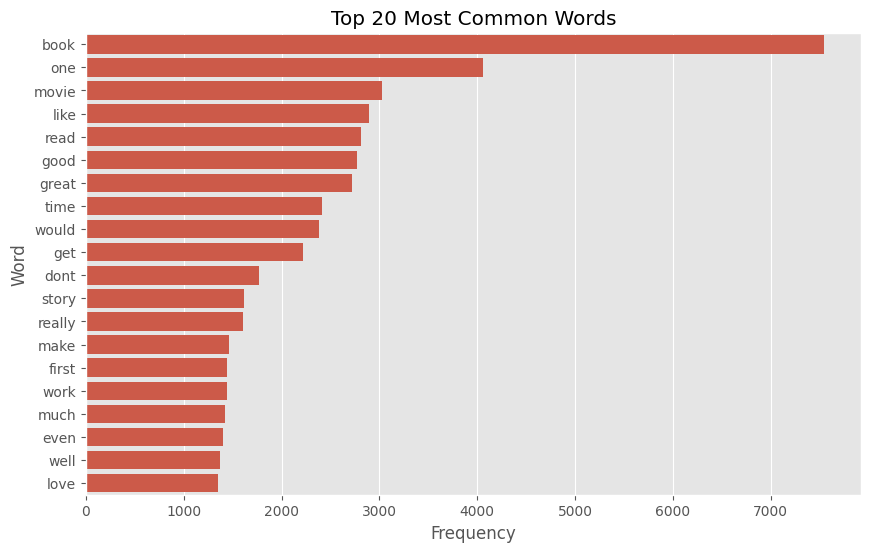

In [146]:
# VISUALIZE TOP 20 WORDS OVERALL

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_words,
    x="Frequency",
    y="Word"
)

plt.title("Top 20 Most Common Words")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

# VISUALIZE TOP 20 WORDS OVERALL

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_words,
    x="Frequency",
    y="Word"
)

plt.title("Top 20 Most Common Words")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

In [147]:

# FEATURE ENGINEERING USING TF-IDF

# Select Features and Target

# Feature (Independent Variable)
X = df["clean_review"]

# Target (Dependent Variable)
y = df["label"]

# Display the first few reviews
X.head()

,clean_review
0,stuning even nongamer sound track beautiful pa...
1,best soundtrack ever anything im reading lot r...
2,amazing soundtrack favorite music time hand in...
3,excellent soundtrack truly like soundtrack enj...
4,remember pull jaw floor hearing youve played g...


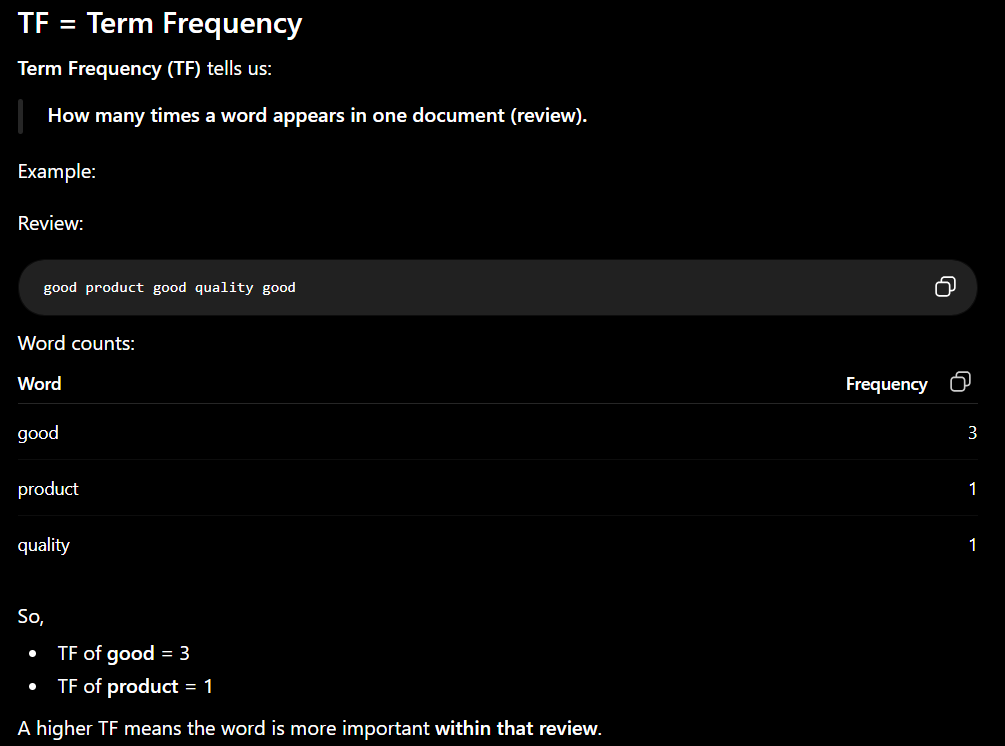

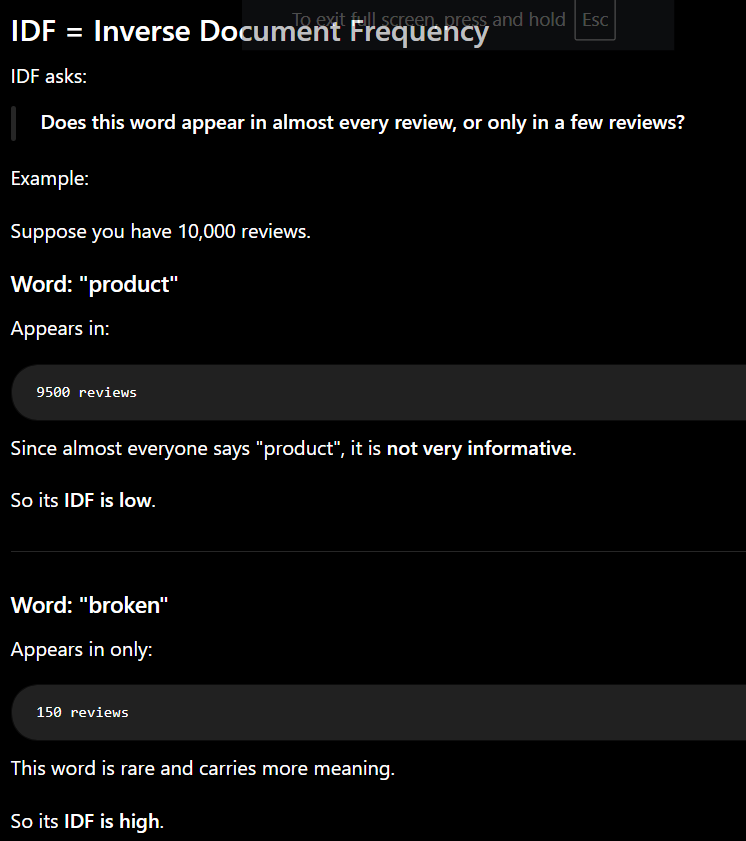

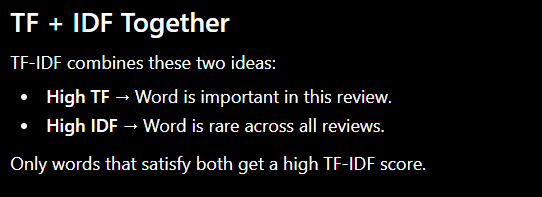

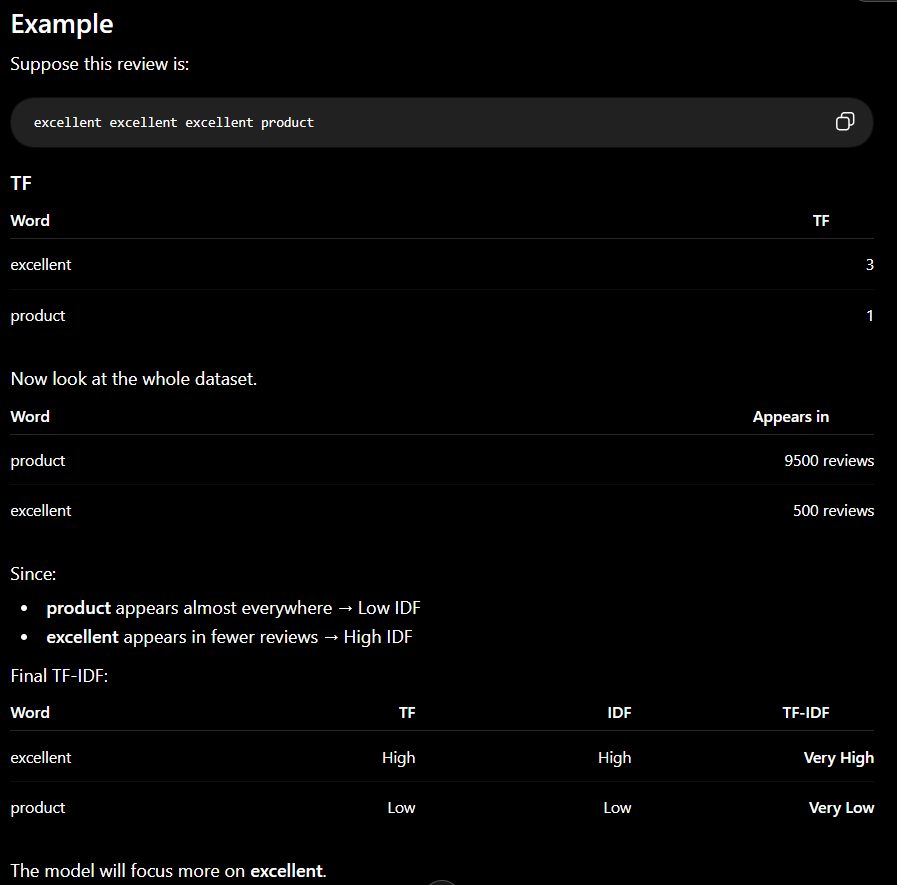

In [148]:
# CONVERT TEXT INTO NUMERICAL FEATURES USING TF-IDF

# Initialize the TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000)

# Fit and Transform the cleaned review text
X = tfidf.fit_transform(X)

# Display the shape of the TF-IDF matrix
print("TF-IDF Matrix Shape :", X.shape)

TF-IDF Matrix Shape : (10000, 5000)


In [149]:
# ENCODE THE TARGET VARIABLE

# Convert Positive -> 1 and Negative -> 0
y = y.map({
    "neg": 0,
    "pos": 1
})

# Display the first few encoded labels
y.head()

,label
0,1
1,1
2,1
3,1
4,1


In [150]:
# VERIFY FEATURES AND TARGET

print("Feature Matrix Shape :", X.shape)
print("Target Shape         :", y.shape)

Feature Matrix Shape : (10000, 5000)
Target Shape         : (10000,)


In [151]:

#TRAIN-TEST SPLIT

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the shapes of the split datasets
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (8000, 5000)
Testing Features  : (2000, 5000)
Training Labels   : (8000,)
Testing Labels    : (2000,)


In [152]:
# VERIFY THE TRAIN-TEST SPLIT

print("Training Data :", round((len(y_train) / len(y)) * 100, 2), "%")
print("Testing Data  :", round((len(y_test) / len(y)) * 100, 2), "%")

Training Data : 80.0 %
Testing Data  : 20.0 %


In [153]:
# TRAIN THE LOGISTIC REGRESSION MODEL

# Create the Logistic Regression model
lr_model = LogisticRegression(random_state=42)

# Train the model
lr_model.fit(X_train, y_train)

print("Logistic Regression Model Trained Successfully.")

Logistic Regression Model Trained Successfully.


In [154]:

# MAKE PREDICTIONS

# Predict on the test data
y_pred_lr = lr_model.predict(X_test)

# Display the first 10 predictions
print(y_pred_lr[:10])

[0 1 0 1 0 0 0 0 1 1]


In [155]:
# MODEL ACCURACY

# Calculate the accuracy of the model
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy :", round(lr_accuracy * 100, 2), "%")

Logistic Regression Accuracy : 84.55 %


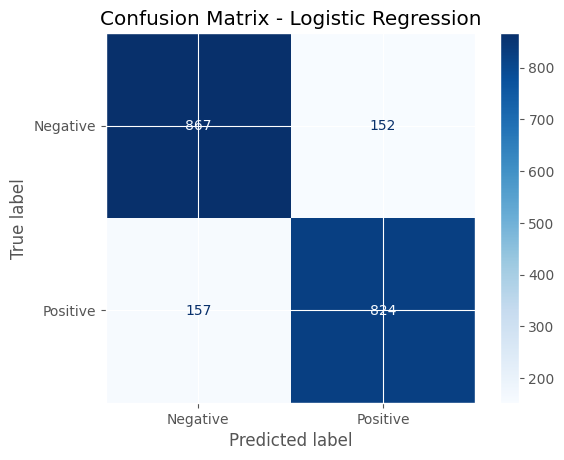

In [156]:

# CONFUSION MATRIX

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")

plt.show()


In [157]:

# CLASSIFICATION REPORT

print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.85      0.85      0.85      1019
    Positive       0.84      0.84      0.84       981

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



In [158]:

# CROSS VALIDATION

# Perform 5-Fold Cross Validation
cv_scores_lr = cross_val_score(
    lr_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores :", cv_scores_lr)

print("Average Cross Validation Accuracy :",
      round(cv_scores_lr.mean() * 100, 2), "%")

Cross Validation Scores : [0.849  0.8265 0.8165 0.827  0.8475]
Average Cross Validation Accuracy : 83.33 %


In [159]:

# PREDICT CUSTOM REVIEWS

# Sample reviews
reviews = [
    "This product is amazing. I really loved it.",
    "Worst product ever. Completely disappointed."
]

# Convert the reviews into TF-IDF features
reviews_tfidf = tfidf.transform(reviews)

# Predict the sentiment
predictions = lr_model.predict(reviews_tfidf)

# Display the results
for review, prediction in zip(reviews, predictions):

    sentiment = "Positive" if prediction == 1 else "Negative"

    print("Review :", review)
    print("Predicted Sentiment :", sentiment)
    print("-" * 60)

Review : This product is amazing. I really loved it.
Predicted Sentiment : Positive
------------------------------------------------------------
Review : Worst product ever. Completely disappointed.
Predicted Sentiment : Negative
------------------------------------------------------------


In [160]:

# TRAIN THE SVM MODEL

# Create the SVM model
svm_model = LinearSVC(random_state=42)

# Train the model
svm_model.fit(X_train, y_train)

print("Support Vector Machine Model Trained Successfully.")

Support Vector Machine Model Trained Successfully.


In [161]:

# MAKE PREDICTIONS

# Predict on the test data
y_pred_svm = svm_model.predict(X_test)

# Display the first 10 predictions
print(y_pred_svm[:10])

[0 1 0 1 0 0 0 0 1 1]


In [162]:

# MODEL ACCURACY

# Calculate the accuracy
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("Support Vector Machine Accuracy :", round(svm_accuracy * 100, 2), "%")

Support Vector Machine Accuracy : 83.45 %


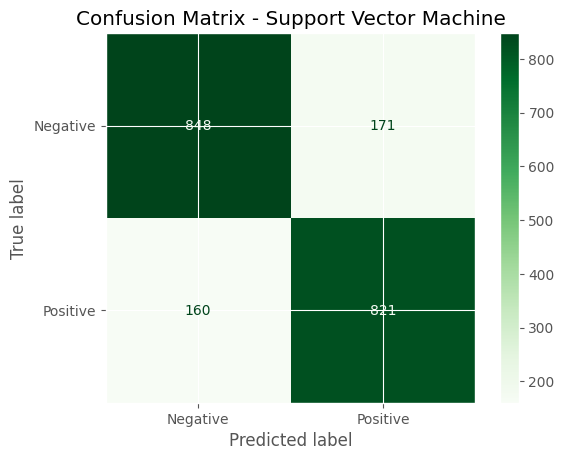

In [163]:

# CONFUSION MATRIX

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot(cmap="Greens")

plt.title("Confusion Matrix - Support Vector Machine")

plt.show()

In [164]:

# CLASSIFICATION REPORT

print(classification_report(
    y_test,
    y_pred_svm,
    target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.84      0.83      0.84      1019
    Positive       0.83      0.84      0.83       981

    accuracy                           0.83      2000
   macro avg       0.83      0.83      0.83      2000
weighted avg       0.83      0.83      0.83      2000



In [165]:

# CROSS VALIDATION

# Perform 5-Fold Cross Validation
cv_scores_svm = cross_val_score(
    svm_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores :", cv_scores_svm)

print("Average Cross Validation Accuracy :",
      round(cv_scores_svm.mean() * 100, 2), "%")

Cross Validation Scores : [0.851  0.8115 0.8115 0.8215 0.84  ]
Average Cross Validation Accuracy : 82.71 %


In [166]:

# PREDICT CUSTOM REVIEWS

# Sample reviews
reviews = [
    "Excellent quality and fast delivery.",
    "I hate this product. Waste of money."
]

# Convert reviews into TF-IDF features
reviews_tfidf = tfidf.transform(reviews)

# Predict the sentiment
predictions = svm_model.predict(reviews_tfidf)

# Display the predictions
for review, prediction in zip(reviews, predictions):

    sentiment = "Positive" if prediction == 1 else "Negative"

    print("Review :", review)
    print("Predicted Sentiment :", sentiment)
    print("-" * 60)

Review : Excellent quality and fast delivery.
Predicted Sentiment : Positive
------------------------------------------------------------
Review : I hate this product. Waste of money.
Predicted Sentiment : Negative
------------------------------------------------------------


In [167]:

# TRAIN THE NEURAL NETWORK MODEL

# Create the Neural Network model
nn_model = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=300,
    random_state=42
)

# Train the model
nn_model.fit(X_train, y_train)

print("Neural Network Model Trained Successfully.")

Neural Network Model Trained Successfully.


In [168]:
# MAKE PREDICTIONS

# Predict on the test data
y_pred_nn = nn_model.predict(X_test)

# Display the first 10 predictions
print(y_pred_nn[:10])

[0 1 0 1 0 0 0 0 1 1]


In [169]:
# MODEL ACCURACY

# Calculate the accuracy
nn_accuracy = accuracy_score(y_test, y_pred_nn)

print("Neural Network Accuracy :", round(nn_accuracy * 100, 2), "%")

Neural Network Accuracy : 80.5 %


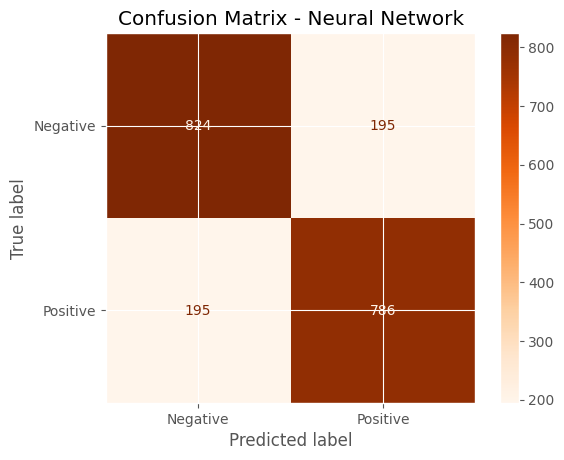

In [170]:
# CONFUSION MATRIX

# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred_nn)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot(cmap="Oranges")

plt.title("Confusion Matrix - Neural Network")

plt.show()

In [171]:

# CLASSIFICATION REPORT

print(classification_report(
    y_test,
    y_pred_nn,
    target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.81      0.81      0.81      1019
    Positive       0.80      0.80      0.80       981

    accuracy                           0.81      2000
   macro avg       0.80      0.80      0.80      2000
weighted avg       0.81      0.81      0.81      2000



In [172]:

# CROSS VALIDATION

# Perform 5-Fold Cross Validation
cv_scores_nn = cross_val_score(
    nn_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores :", cv_scores_nn)

print("Average Cross Validation Accuracy :",
      round(cv_scores_nn.mean() * 100, 2), "%")

Cross Validation Scores : [0.8105 0.776  0.776  0.79   0.796 ]
Average Cross Validation Accuracy : 78.97 %


In [173]:

# PREDICT CUSTOM REVIEWS

# Sample reviews
reviews = [
    "Amazing product. I will definitely buy it again.",
    "Terrible quality. Completely useless."
]

# Convert reviews into TF-IDF features
reviews_tfidf = tfidf.transform(reviews)

# Predict the sentiment
predictions = nn_model.predict(reviews_tfidf)

# Display the predictions
for review, prediction in zip(reviews, predictions):

    sentiment = "Positive" if prediction == 1 else "Negative"

    print("Review :", review)
    print("Predicted Sentiment :", sentiment)
    print("-" * 60)

Review : Amazing product. I will definitely buy it again.
Predicted Sentiment : Positive
------------------------------------------------------------
Review : Terrible quality. Completely useless.
Predicted Sentiment : Negative
------------------------------------------------------------


In [174]:

# MODEL COMPARISON

# Create a DataFrame to compare all models
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Support Vector Machine",
        "Neural Network"
    ],
    "Accuracy (%)": [
        round(lr_accuracy * 100, 2),
        round(svm_accuracy * 100, 2),
        round(nn_accuracy * 100, 2)
    ],
    "Cross Validation (%)": [
        round(cv_scores_lr.mean() * 100, 2),
        round(cv_scores_svm.mean() * 100, 2),
        round(cv_scores_nn.mean() * 100, 2)
    ]
})

model_results

,Model,Accuracy (%),Cross Validation (%)
0,Logistic Regression,84.55,83.33
1,Support Vector Machine,83.45,82.71
2,Neural Network,80.50,78.97


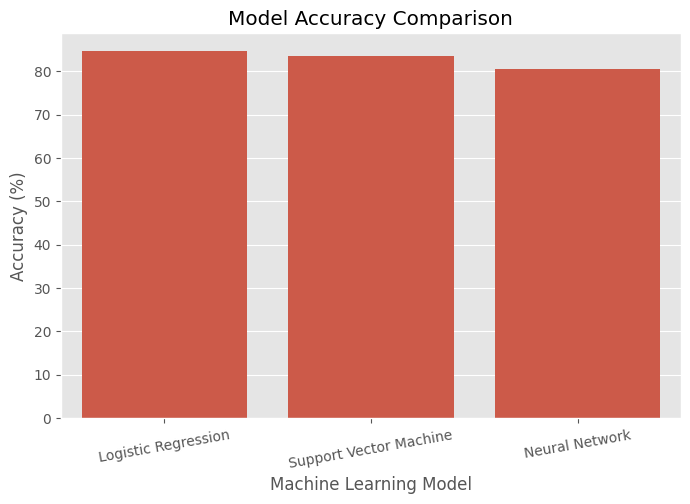

In [175]:
# VISUALIZE MODEL COMPARISON

plt.figure(figsize=(8,5))

sns.barplot(
    data=model_results,
    x="Model",
    y="Accuracy (%)"
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")

plt.xticks(rotation=10)

plt.show()

In [176]:
# BEST PERFORMING MODEL

best_model = model_results.loc[
    model_results["Accuracy (%)"].idxmax()
]

print("Best Performing Model")
print(best_model)

Best Performing Model
Model                   Logistic Regression
Accuracy (%)                          84.55
Cross Validation (%)                  83.33
Name: 0, dtype: object


In [177]:
# FINAL MODEL COMPARISON

model_results.sort_values(
    by="Accuracy (%)",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy (%),Cross Validation (%)
0,Logistic Regression,84.55,83.33
1,Support Vector Machine,83.45,82.71
2,Neural Network,80.50,78.97


####Conclusion

This project successfully developed an automated sentiment analysis system for Amazon customer reviews using Natural Language Processing techniques. After preprocessing the text and extracting features using TF-IDF, Logistic Regression, Linear SVM, and Neural Network models were trained and evaluated. The results demonstrate that machine learning can effectively classify customer reviews into positive and negative sentiments, providing valuable insights that can help businesses monitor customer feedback and improve customer satisfaction.